In [1]:
# start by loading in relevant packages
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plot
import joblib

pd.set_option("display.float_format", "{:,.2f}".format) # random formatting stuff

# saving the training data to training_data
training_data=pd.read_csv("/Users/annakpope/Downloads/fim500 : project/model documentation/data/cs-training.csv.zip")

#

In [8]:
y = training_data["SeriousDlqin2yrs"] # defining the target variable
x = training_data[["MonthlyIncome","DebtRatio","NumberOfTimes90DaysLate","RevolvingUtilizationOfUnsecuredLines","NumberOfTime30-59DaysPastDueNotWorse", "NumberOfTime60-89DaysPastDueNotWorse","NumberOfDependents","NumberOfOpenCreditLinesAndLoans", "NumberRealEstateLoansOrLines","age"]] # defining the features

# importing the model and scaling functions
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=.20,
    random_state=42,
    stratify=y
) # splitting the training and the testing data up for this model

# cleaning the data, using the median monthly income to fill missing values
median_income = x_train["MonthlyIncome"].median()
median_depend = x_train["NumberOfDependents"].median()
x_train["MonthlyIncome"]=x_train["MonthlyIncome"].fillna(median_income)
x_test["MonthlyIncome"] = x_test["MonthlyIncome"].fillna(median_income)
x_train["NumberOfDependents"]=x_train["NumberOfDependents"].fillna(median_depend)
x_test["NumberOfDependents"]=x_test["NumberOfDependents"].fillna(median_depend)

upper_bound = training_data["RevolvingUtilizationOfUnsecuredLines"].quantile(0.85)
upper_bound_income = training_data["MonthlyIncome"].quantile(0.75)

training_data["RevolvingUtilizationOfUnsecuredLines"] = training_data["RevolvingUtilizationOfUnsecuredLines"].clip(upper= upper_bound)
training_data["MonthlyIncome"] = training_data["MonthlyIncome"].clip(upper=upper_bound_income)

# scaling the training and testing data sets
scaling = StandardScaler()
x_train_scaled=scaling.fit_transform(x_train)
x_test_scaled=scaling.transform(x_test)

# creating the logistic regression model
my_model=LogisticRegression()
my_model.fit(x_train_scaled,y_train) # fitting the model using the training data

# saving everything to import into the python code space
joblib.dump(my_model, "my_model.pkl")
joblib.dump(scaling, "scaling.pkl")
joblib.dump(median_income, "median_income.pkl")


['median_income.pkl']

In [3]:
# applying the model to the testing data set
pd_predictions = my_model.predict_proba(x_test_scaled)[:,1]
borrowers = np.arange(1, len(pd_predictions) + 1)

# printing out/formating the final table for the testing data set
pd_table = pd.DataFrame({
    'Borrower': borrowers,
    'PD (%)': pd_predictions*100
})


In [4]:
# creating and playing around with the function for the model created.

def predict_pd(new_data):
    
    # Select the variables used by the model
    x_new = new_data[[
        "MonthlyIncome",
        "DebtRatio",
        "NumberOfTimes90DaysLate",
        "RevolvingUtilizationOfUnsecuredLines",
        "NumberOfTime30-59DaysPastDueNotWorse",
        "NumberOfTime60-89DaysPastDueNotWorse",
        "NumberOfDependents",
        "NumberOfOpenCreditLinesAndLoans",
        "NumberRealEstateLoansOrLines",
        "age"
    ]].copy()
    
    # Handle missing MonthlyIncome
    x_new["MonthlyIncome"] = x_new["MonthlyIncome"].fillna(median_income)
    x_new["NumberOfDependents"]=x_new["NumberOfDependents"].fillna(median_depend)
    x_new["RevolvingUtilizationOfUnsecuredLines"]=x_new["RevolvingUtilizationOfUnsecuredLines"].clip(upper=upper_bound)
    
    # Use the scaler that was fitted on the original training data
    x_new_scaled = scaling.transform(x_new)
    
    # Predict probability of serious delinquency
    pd_predictions = my_model.predict_proba(x_new_scaled)[:, 1]
    
    # Create output table
    pd_table = pd.DataFrame({
        "Borrower": np.arange(1, len(pd_predictions) + 1),
        "PD (%)": pd_predictions*100
    })
    
    return pd_table

### Pre-Validation Testing and Graphs Below! Beware!

In [67]:
# random test to see if everything loads in properly with the function
new_data_test = pd.read_csv("/Users/annakpope/Downloads/fim500 : project/model documentation/data/cs-test.csv.zip")

new_predictions = predict_pd(new_data_test)
new_predictions


# accuracy test i guess
predictions=predict_pd(training_data)
training_data

accuracy_ds = pd.concat([training_data, predictions], axis=1)
accuracy_ds.columns

small=accuracy_ds[["SeriousDlqin2yrs","PD (%)"]]

predict_test=(accuracy_ds["PD (%)"]>=20).astype(int) # if the predicted probability of default >50%, then let's say it defaulted

acc = pd.concat([small,predict_test],axis=1)
acc.columns=[
    "Delq",
    "PD",
    "Predicted_Delq"
] # dataset w/ all the variables for checking accuracies

from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve

t=confusion_matrix(acc["Delq"],acc["Predicted_Delq"])
tn, fp, fn, tp=t.ravel()

In [44]:
recall = tp / (tp+fn)
precision = tp / (tp+fp)
accuracy = (tp+tn) / (tn+fp+fn+tp)

print('recall', recall*100, 'precision', precision*100, 'accuracy', accuracy*100) # high recall, low precision and okay accuracy

recall 34.679832435667265 precision 31.315860578222104 accuracy 90.55


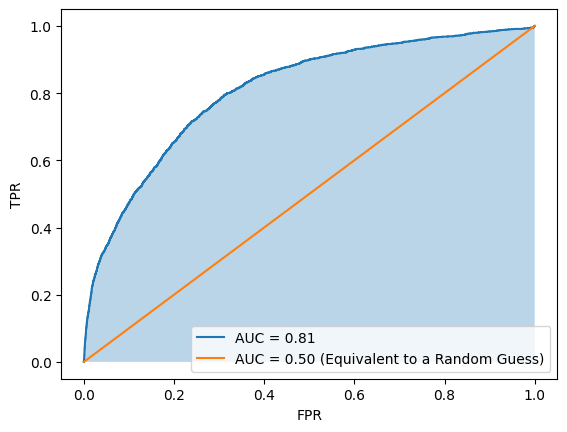

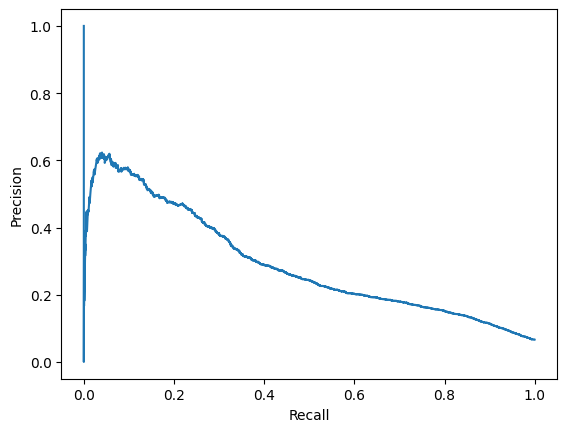

0.8088124927901715


In [65]:
# redoing accurary test

pd_predictions = my_model.predict_proba(x_test_scaled)[:, 1]

auc = roc_auc_score(y_test, pd_predictions)

fpr, tpr, thresholds = roc_curve(
    y_test,
    pd_predictions
)

precision, recall, thresholds_pr = precision_recall_curve(
    y_test,
    pd_predictions
)

plot.plot(fpr, tpr, label="AUC = 0.81")
plot.fill_between(fpr, tpr, alpha=0.3)
plot.xlabel("FPR")
plot.ylabel("TPR")
plot.plot([0,1],[0,1], label="AUC = 0.50 (Equivalent to a Random Guess)")
plot.legend(loc=4)
plot.show()

plot.plot(recall, precision)
plot.xlabel("Recall")
plot.ylabel("Precision")
plot.show()
print(auc)